### Importing Modules


In [1]:
# for data analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# for classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
# CNN
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import TimeDistributed, Conv1D, MaxPooling1D, Flatten, Dense
from tensorflow.keras.layers import Input, Dropout, Activation, ZeroPadding2D, BatchNormalization, Flatten, Conv2D, Embedding, Add
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

# for evaluation
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report, confusion_matrix

#for oversampling
from sklearn.preprocessing import StandardScaler
from sklearn.utils import class_weight, resample
from imblearn.over_sampling import RandomOverSampler, SMOTE


## Importing Data

In [2]:
cols = [i for i in range(0,188)]
df = pd.read_csv('mitbih_test.csv', names = cols)
df.head()

,0,1,2,3,4,5,6,7,8,9,...,178,179,180,181,182,183,184,185,186,187
0,1.000000,0.758264,0.111570,0.000000,0.080579,0.078512,0.066116,0.049587,0.047521,0.035124,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.908425,0.783883,0.531136,0.362637,0.366300,0.344322,0.333333,0.307692,0.296703,0.300366,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.730088,0.212389,0.000000,0.119469,0.101770,0.101770,0.110619,0.123894,0.115044,0.132743,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.000000,0.910417,0.681250,0.472917,0.229167,0.068750,0.000000,0.004167,0.014583,0.054167,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.570470,0.399329,0.238255,0.147651,0.000000,0.003356,0.040268,0.080537,0.070470,0.090604,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
df[187] = df[187].map(lambda x: 0 if x ==0 else 1)

In [4]:
smote = SMOTE (sampling_strategy='all',random_state=42)
x =df.drop (columns =187)
y = df[187]
x,y = smote.fit_resample (x,y)
df = pd.concat([x,y],axis = 1)

In [5]:
pd.unique(df[187])

array([0, 1])

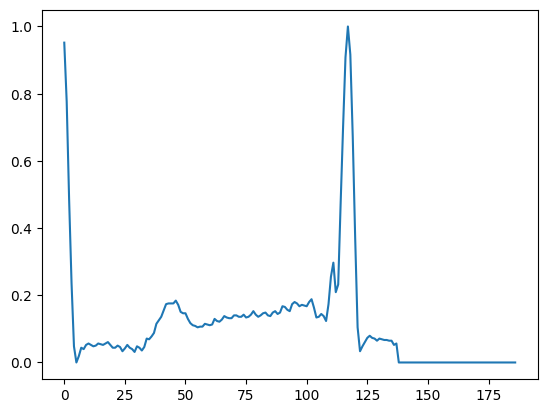

In [6]:
plt.plot ( (df.loc [df[187] ==0]).sample(1).iloc [:,:-1].values[0])

Different Types Of Beat

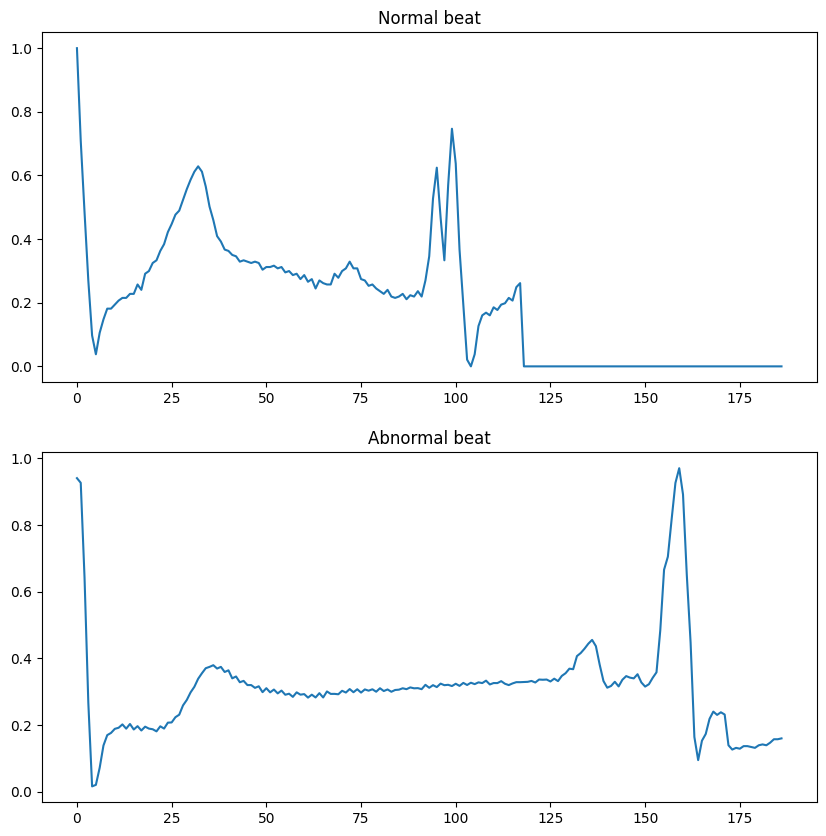

In [7]:
plt.figure(figsize=(10,10))

plt.subplot(2,1,1)
plt.plot (range (0,187), (df.loc [df[187] ==0]).sample(1).iloc [:,:-1].values[0] )
plt.title ('Normal beat')

plt.subplot(2,1,2)
plt.plot ( (df.loc [df[187] ==1]).sample(1).iloc [:,:-1].values[0])
plt.title ('Abnormal beat')

plt.show()

In [8]:
# # Split the data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 42)

------------------------------------

# KNN

In [9]:
knn_model = KNeighborsClassifier(n_neighbors=6)
knn_model.fit(x_train, y_train)

KNeighborsClassifier(n_neighbors=6)

In [10]:
y_pred = knn_model.predict(x_test)

In [11]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.97      0.97      5435
           1       0.97      0.98      0.97      5436

    accuracy                           0.97     10871
   macro avg       0.97      0.97      0.97     10871
weighted avg       0.97      0.97      0.97     10871



<Axes: >

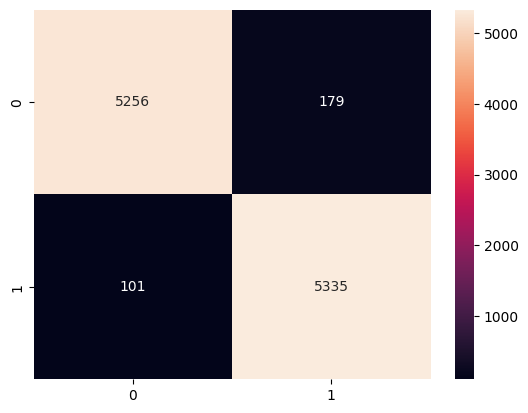

In [12]:
sns.heatmap(confusion_matrix(y_test,y_pred), annot = True, fmt='d')

---------------------------------------------------------------------

# Logistic Regression

In [ ]:
lg_model = LogisticRegression()
lg_model.fit(x_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
y_pred_lg = lg_model.predict(x_test)

In [ ]:
print(classification_report(y_test, y_pred_lg))

              precision    recall  f1-score   support

         0.0       0.78      0.84      0.81      3110
         1.0       0.83      0.77      0.80      3194

    accuracy                           0.80      6304
   macro avg       0.80      0.80      0.80      6304
weighted avg       0.80      0.80      0.80      6304



<Axes: >

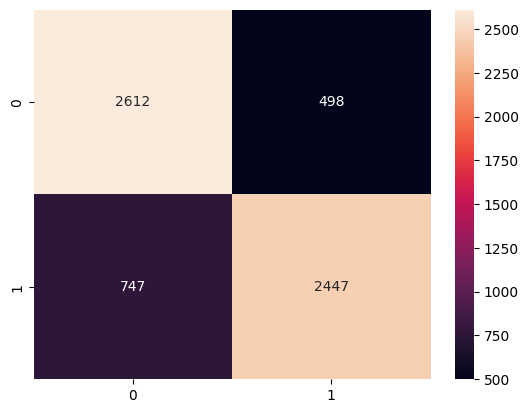

In [ ]:
sns.heatmap(confusion_matrix(y_test,y_pred_lg), annot = True, fmt='d')

--------------------------------

# Random Forest Classifier

In [ ]:
rfc_model = RandomForestClassifier()
rfc_model.fit(x_train, y_train)

RandomForestClassifier()

In [ ]:
y_pred_rfc = rfc_model.predict(x_test)

In [ ]:
print(classification_report(y_test, y_pred_rfc))

              precision    recall  f1-score   support

         0.0       0.98      0.99      0.98      3110
         1.0       0.99      0.98      0.98      3194

    accuracy                           0.98      6304
   macro avg       0.98      0.98      0.98      6304
weighted avg       0.98      0.98      0.98      6304



<Axes: >

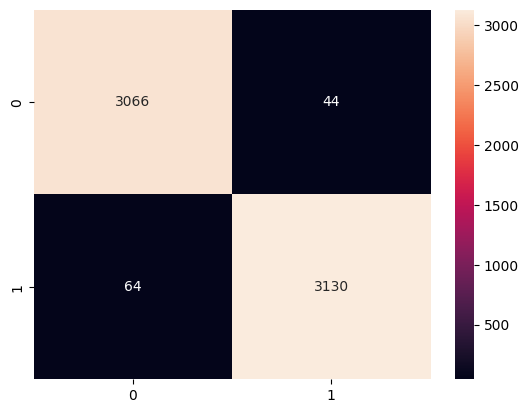

In [ ]:
sns.heatmap(confusion_matrix(y_test,y_pred_rfc), annot = True, fmt='d')

## CNN Binary

In [ ]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

In [ ]:
# Build the Time Distributed CNN model
bin_model = Sequential([
    Conv1D(filters=32, kernel_size=5, activation='relu', input_shape=(187, 1)),
    MaxPooling1D(pool_size=2),
    Conv1D(filters=64, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])


In [ ]:
# Compile the model
bin_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
# Train the model
bin_model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/20
793/793 [==============================] - 13s 14ms/step - loss: 0.3048 - accuracy: 0.8658 - val_loss: 0.1946 - val_accuracy: 0.9227
Epoch 2/20
793/793 [==============================] - 11s 14ms/step - loss: 0.1895 - accuracy: 0.9257 - val_loss: 0.1517 - val_accuracy: 0.9407
Epoch 3/20
793/793 [==============================] - 12s 15ms/step - loss: 0.1610 - accuracy: 0.9367 - val_loss: 0.1271 - val_accuracy: 0.9549
Epoch 4/20
793/793 [==============================] - 11s 14ms/step - loss: 0.1361 - accuracy: 0.9505 - val_loss: 0.1131 - val_accuracy: 0.9594
Epoch 5/20
793/793 [==============================] - 11s 14ms/step - loss: 0.1197 - accuracy: 0.9562 - val_loss: 0.1000 - val_accuracy: 0.9661
Epoch 6/20
793/793 [==============================] - 11s 14ms/step - loss: 0.1061 - accuracy: 0.9612 - val_loss: 0.0862 - val_accuracy: 0.9705
Epoch 7/20
793/793 [==============================] - 11s 14ms/step - loss: 0.0959 - accuracy: 0.9651 - val_loss: 0.0780 - val_accuracy:

In [ ]:
# Evaluate the model
score = bin_model.evaluate(X_test,y_test, verbose=1)
predictions = bin_model.predict(X_test)
y_pred = np.round(predictions).flatten()

340/340 [==============================] - 2s 5ms/step


In [ ]:
# Classification report and confusion matrix
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.98      0.98      5435
           1       0.98      0.99      0.98      5436

    accuracy                           0.98     10871
   macro avg       0.98      0.98      0.98     10871
weighted avg       0.98      0.98      0.98     10871

[[5338   97]
 [  67 5369]]


In [ ]:
bin_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d (Conv1D)             (None, 183, 32)           192       
                                                                 
 max_pooling1d (MaxPooling1  (None, 91, 32)            0         
 D)                                                              
                                                                 
 conv1d_1 (Conv1D)           (None, 89, 64)            6208      
                                                                 
 max_pooling1d_1 (MaxPoolin  (None, 44, 64)            0         
 g1D)                                                            
                                                                 
 flatten (Flatten)           (None, 2816)              0         
                                                                 
 dense (Dense)               (None, 64)                1

<Axes: >

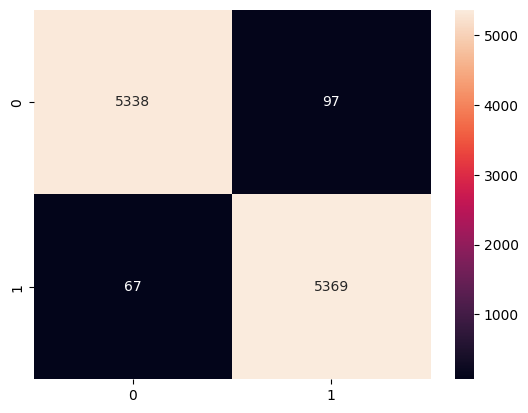

In [ ]:
sns.heatmap(confusion_matrix(y_test,y_pred), annot = True, fmt='d')

In [ ]:
import pickle
with open('bin_model.pkl','wb') as file:
  pickle.dump(bin_model, file)

In [ ]:
with open('bin_model.pkl','rb') as file:
  data = pickle.load(file)

In [ ]:
y_predddd = np.round(data.predict(X_test)).flatten()

340/340 [==============================] - 2s 5ms/step


In [ ]:
print(classification_report(y_test, y_predddd))

              precision    recall  f1-score   support

           0       0.99      0.98      0.98      5435
           1       0.98      0.99      0.98      5436

    accuracy                           0.98     10871
   macro avg       0.98      0.98      0.98     10871
weighted avg       0.98      0.98      0.98     10871



In [ ]:
my_test = np.array((df.loc [df[187] ==1]).sample(1).iloc [:,:-1].values[0] )

In [ ]:
my_test = my_test.reshape(1, 187, 1)

In [ ]:
new_ypred = bin_model.predict(my_test)

1/1 [==============================] - 0s 173ms/step


In [ ]:
np.round(new_ypred).flatten()

array([1.], dtype=float32)

## CNN Multiclass

In [ ]:
cols = [i for i in range(0,188)]
df = pd.read_csv('mitbih_test.csv', names = cols)
df.head()

,0,1,2,3,4,5,6,7,8,9,...,178,179,180,181,182,183,184,185,186,187
0,1.000000,0.758264,0.111570,0.000000,0.080579,0.078512,0.066116,0.049587,0.047521,0.035124,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.908425,0.783883,0.531136,0.362637,0.366300,0.344322,0.333333,0.307692,0.296703,0.300366,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.730088,0.212389,0.000000,0.119469,0.101770,0.101770,0.110619,0.123894,0.115044,0.132743,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.000000,0.910417,0.681250,0.472917,0.229167,0.068750,0.000000,0.004167,0.014583,0.054167,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.570470,0.399329,0.238255,0.147651,0.000000,0.003356,0.040268,0.080537,0.070470,0.090604,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
df.tail()

,0,1,2,3,4,5,6,7,8,9,...,178,179,180,181,182,183,184,185,186,187
21887,0.928736,0.871264,0.804598,0.742529,0.650575,0.535632,0.394253,0.250575,0.140230,0.102299,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0
21888,0.802691,0.692078,0.587444,0.446936,0.318386,0.189836,0.118087,0.077728,0.112108,0.152466,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0
21889,1.000000,0.967359,0.620178,0.347181,0.139466,0.089021,0.103858,0.100890,0.106825,0.100890,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0
21890,0.984127,0.567460,0.607143,0.583333,0.607143,0.575397,0.575397,0.488095,0.392857,0.238095,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0
21891,0.973970,0.913232,0.865510,0.823210,0.746204,0.642082,0.547722,0.426247,0.325380,0.279826,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0


In [ ]:
pd.unique(df[187])

array([0., 1., 2., 3., 4.])

In [ ]:
df[187].count()

21892

In [ ]:
df[187].value_counts()

187
0.0    18118
4.0     1608
2.0     1448
1.0      556
3.0      162
Name: count, dtype: int64

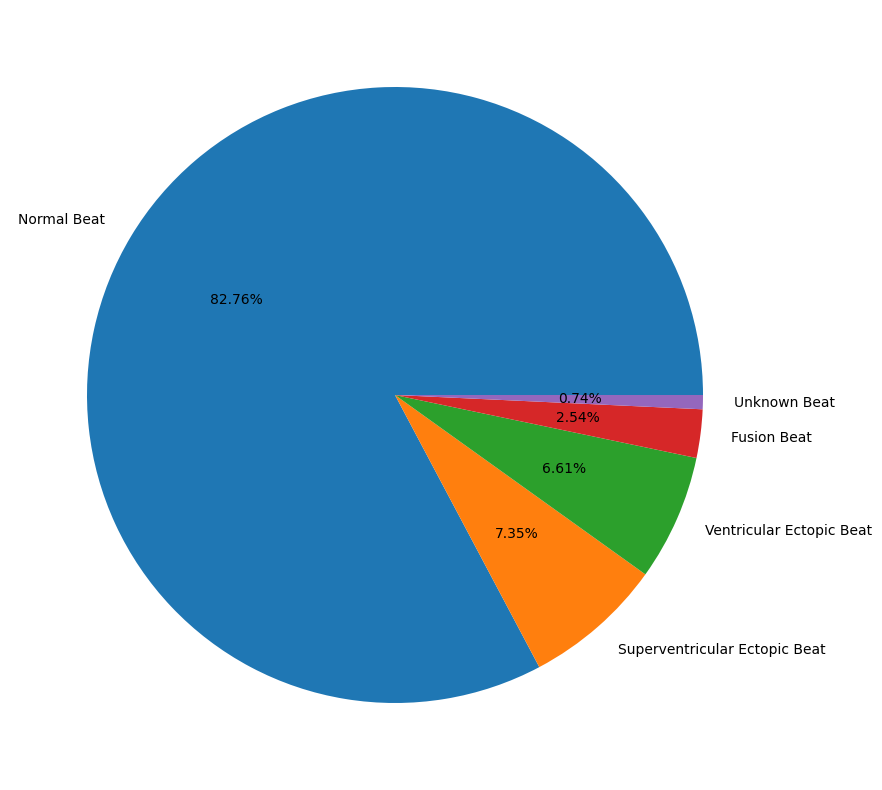

In [ ]:
Beats = ['Normal Beat', 'Superventricular Ectopic Beat', 'Ventricular Ectopic Beat', 'Fusion Beat','Unknown Beat']
plt.figure(figsize=(10,10))
plt.pie (df[187].value_counts().values,labels = Beats,autopct='%.2f%%')
plt.show()

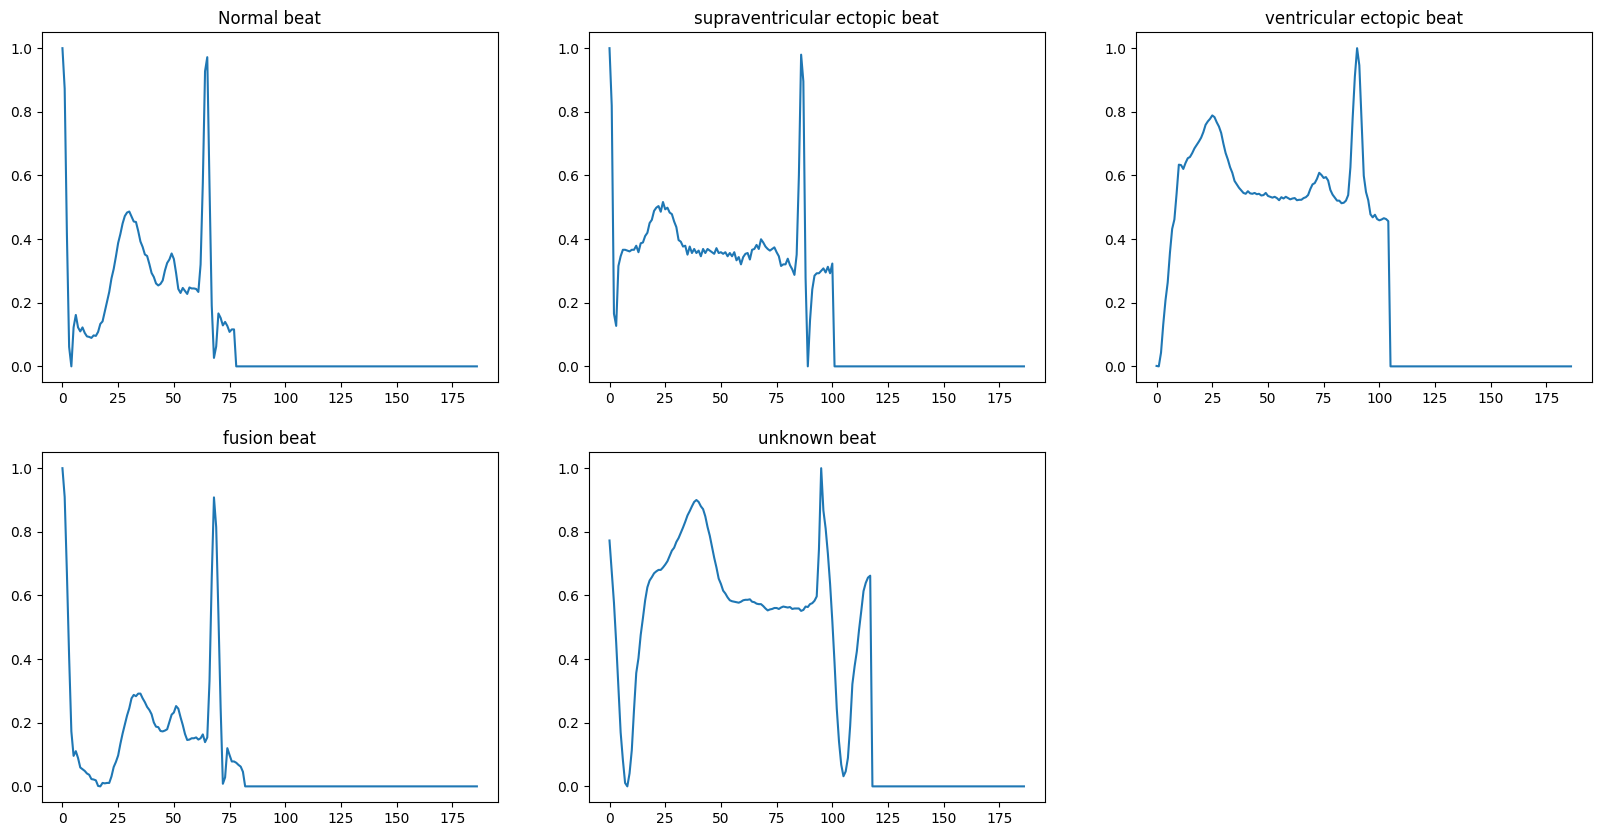

In [ ]:
plt.figure(figsize=(20,10))

plt.subplot(2,3,1)
plt.plot (range (0,187), (df.loc [df[187] ==0]).sample(1).iloc [:,:-1].values[0] )
plt.title ('Normal beat')

plt.subplot(2,3,2)
plt.plot ( (df.loc [df[187] ==1]).sample(1).iloc [:,:-1].values[0])
plt.title ('supraventricular ectopic beat')

plt.subplot(2,3,3)
plt.plot ( (df.loc [df[187] ==2]).sample(1).iloc [:,:-1].values[0])
plt.title ('ventricular ectopic beat')

plt.subplot(2,3,4)
plt.plot ( (df.loc [df[187] ==3]).sample(1).iloc [:,:-1].values[0])
plt.title ('fusion beat')

plt.subplot(2,3,5)
plt.plot ( (df.loc [df[187] ==4]).sample(1).iloc [:,:-1].values[0])
plt.title ('unknown beat')

plt.show()

In [ ]:
smote = SMOTE (sampling_strategy='all',random_state=42)
x =df.drop (columns =187)
y = df[187]
x,y = smote.fit_resample (x,y)
df = pd.concat([x,y],axis = 1)

In [ ]:
df[187].value_counts()

187
0.0    18118
1.0    18118
2.0    18118
3.0    18118
4.0    18118
Name: count, dtype: int64

In [ ]:
df_0 = df[df[187]==0.0].sample(n=4000, random_state=1)
df_1 = df[df[187]==1.0].sample(n=4000, random_state=1)
df_2 = df[df[187]==2.0].sample(n=4000, random_state=1)
df_3 = df[df[187]==3.0].sample(n=4000, random_state=1)
df_4 = df[df[187]==4.0].sample(n=4000, random_state=1)

df = pd.concat([df_0, df_1, df_2, df_3,df_4 ])

In [ ]:
df[187].value_counts()

187
0.0    4000
1.0    4000
2.0    4000
3.0    4000
4.0    4000
Name: count, dtype: int64

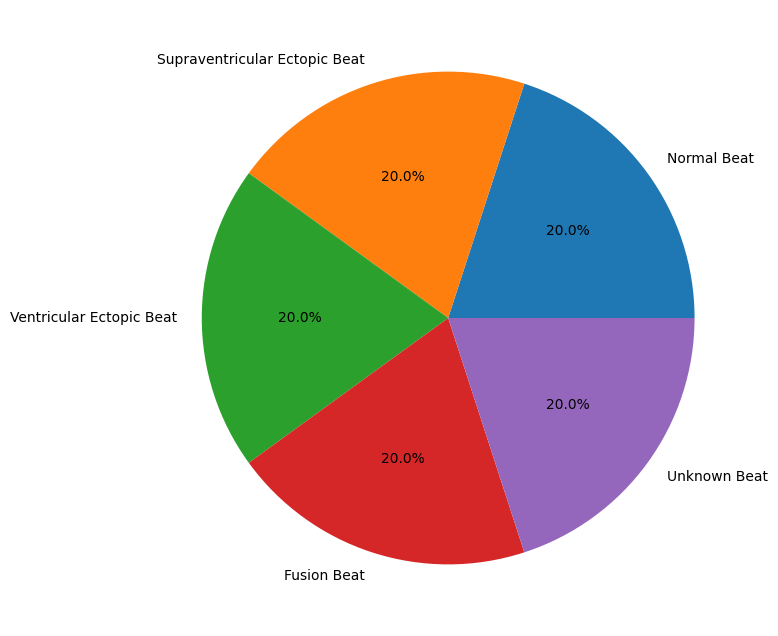

In [ ]:
plt.figure(figsize=(8,8))
Labels = ['Normal Beat', 'Supraventricular Ectopic Beat', 'Ventricular Ectopic Beat', 'Fusion Beat', 	'Unknown Beat']
plt.pie(df[187].value_counts().values, labels = Labels, autopct='%1.1f%%')
plt.show()

In [ ]:
# Split the data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 42)

In [ ]:
# Build the Time Distributed CNN model
multi_model = Sequential([
    Conv1D(128,3,input_shape=(x_train.shape[1],1), activation='relu'),
    MaxPooling1D(pool_size=2),
    Conv1D(64,3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Conv1D(64,2, activation='relu'),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dense(5, activation='softmax')
])

In [ ]:
# Compile the model
multi_model.compile(loss='sparse_categorical_crossentropy',optimizer='adam',metrics=['accuracy'])
multi_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d (Conv1D)             (None, 185, 128)          512       
                                                                 
 max_pooling1d (MaxPooling1  (None, 92, 128)           0         
 D)                                                              
                                                                 
 conv1d_1 (Conv1D)           (None, 90, 64)            24640     
                                                                 
 max_pooling1d_1 (MaxPoolin  (None, 45, 64)            0         
 g1D)                                                            
                                                                 
 conv1d_2 (Conv1D)           (None, 44, 64)            8256      
                                                                 
 max_pooling1d_2 (MaxPoolin  (None, 22, 64)            0

In [ ]:
# Train the model
multi_model.fit(x_train, y_train, epochs=10, batch_size=32, validation_data=(x_test,y_test))

Epoch 1/10
1982/1982 [==============================] - 58s 28ms/step - loss: 0.3620 - accuracy: 0.8655 - val_loss: 0.1392 - val_accuracy: 0.9491
Epoch 2/10
1982/1982 [==============================] - 56s 28ms/step - loss: 0.1616 - accuracy: 0.9432 - val_loss: 0.0876 - val_accuracy: 0.9659
Epoch 3/10
1982/1982 [==============================] - 56s 28ms/step - loss: 0.1120 - accuracy: 0.9608 - val_loss: 0.0620 - val_accuracy: 0.9783
Epoch 4/10
1982/1982 [==============================] - 127s 64ms/step - loss: 0.0866 - accuracy: 0.9699 - val_loss: 0.0441 - val_accuracy: 0.9861
Epoch 5/10
1982/1982 [==============================] - 54s 27ms/step - loss: 0.0713 - accuracy: 0.9758 - val_loss: 0.0416 - val_accuracy: 0.9858
Epoch 6/10
1982/1982 [==============================] - 54s 27ms/step - loss: 0.0610 - accuracy: 0.9797 - val_loss: 0.0382 - val_accuracy: 0.9867
Epoch 7/10
1982/1982 [==============================] - 54s 27ms/step - loss: 0.0538 - accuracy: 0.9820 - val_loss: 0.0322 

In [ ]:
# Evaluate the model
score = multi_model.evaluate(x_test,y_test, verbose=1)
y_predict = multi_model.predict(x_test)

850/850 [==============================] - 8s 9ms/step


              precision    recall  f1-score   support

         0.0       0.99      0.98      0.98      5389
         1.0       0.98      0.99      0.99      5511
         2.0       1.00      0.99      0.99      5428
         3.0       0.99      1.00      1.00      5451
         4.0       1.00      1.00      1.00      5398

    accuracy                           0.99     27177
   macro avg       0.99      0.99      0.99     27177
weighted avg       0.99      0.99      0.99     27177



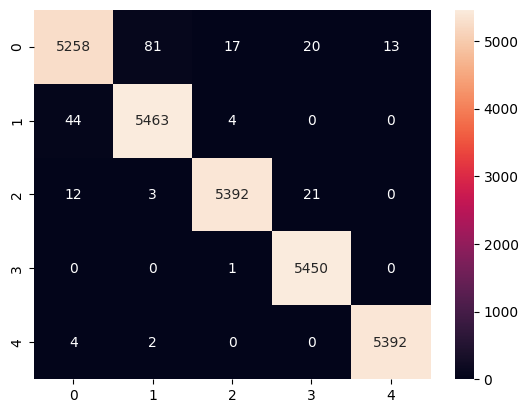

In [ ]:
# Classification report and confusion matrix
y_predict = np.argmax(multi_model.predict (x_test,verbose = 0),axis =1)
sns.heatmap(confusion_matrix(y_test,y_predict),annot = True,fmt='d')
print (classification_report (y_test,y_predict))

In [ ]:
import pickle

In [ ]:
with open('multi_model.pkl','wb') as file:
  pickle.dump(multi_model, file)

In [ ]:
with open('multi_model.pkl','rb') as file:
  mdata = pickle.load(file)

In [ ]:
multiy_pred = np.argmax(mdata.predict(x_test, verbose =0), axis = 1).flatten()
print(classification_report(y_test, multiy_pred))

              precision    recall  f1-score   support

         0.0       0.99      0.98      0.98      5389
         1.0       0.98      0.99      0.99      5511
         2.0       1.00      0.99      0.99      5428
         3.0       0.99      1.00      1.00      5451
         4.0       1.00      1.00      1.00      5398

    accuracy                           0.99     27177
   macro avg       0.99      0.99      0.99     27177
weighted avg       0.99      0.99      0.99     27177



In [ ]:
my_test = np.array((df.loc [df[187] ==4]).sample(1).iloc [:,:-1].values[0] )
my_test = my_test.reshape(1, 187, 1)
new_ypred = multi_model.predict(my_test)
np.round(new_ypred).flatten()

1/1 [==============================] - 0s 218ms/step


array([0., 0., 0., 0., 1.], dtype=float32)

In [ ]:
# # Split the data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 42)

------------------------------------

# KNN

In [ ]:
knn_model = KNeighborsClassifier(n_neighbors=6)
knn_model.fit(x_train, y_train)

KNeighborsClassifier(n_neighbors=6)

              precision    recall  f1-score   support

         0.0       1.00      0.93      0.96      5389
         1.0       0.97      1.00      0.98      5511
         2.0       0.98      1.00      0.99      5428
         3.0       0.99      1.00      0.99      5451
         4.0       0.99      1.00      1.00      5398

    accuracy                           0.99     27177
   macro avg       0.99      0.99      0.99     27177
weighted avg       0.99      0.99      0.99     27177



<Axes: >

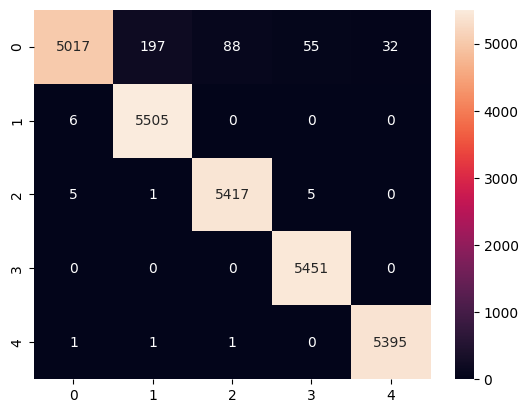

In [ ]:
y_pred = knn_model.predict(x_test)
print(classification_report(y_test, y_pred))
sns.heatmap(confusion_matrix(y_test,y_pred), annot = True, fmt='d')

---------------------------------------------------------------------

# Logistic Regression

In [ ]:
lg_model = LogisticRegression()
lg_model.fit(x_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

              precision    recall  f1-score   support

         0.0       0.64      0.63      0.63      5389
         1.0       0.82      0.75      0.78      5511
         2.0       0.76      0.82      0.79      5428
         3.0       0.88      0.93      0.91      5451
         4.0       0.95      0.92      0.93      5398

    accuracy                           0.81     27177
   macro avg       0.81      0.81      0.81     27177
weighted avg       0.81      0.81      0.81     27177



<Axes: >

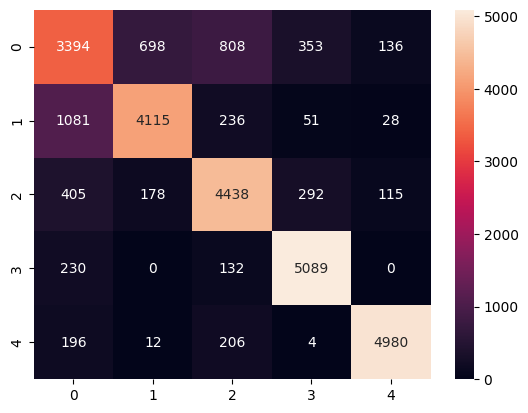

In [ ]:
y_pred_lg = lg_model.predict(x_test)
print(classification_report(y_test, y_pred_lg))
sns.heatmap(confusion_matrix(y_test,y_pred_lg), annot = True, fmt='d')

--------------------------------

# Random Forest Classifier

In [ ]:
rfc_model = RandomForestClassifier()
rfc_model.fit(x_train, y_train)

RandomForestClassifier()

              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99      5389
         1.0       0.99      1.00      0.99      5511
         2.0       1.00      1.00      1.00      5428
         3.0       1.00      1.00      1.00      5451
         4.0       1.00      1.00      1.00      5398

    accuracy                           1.00     27177
   macro avg       1.00      1.00      1.00     27177
weighted avg       1.00      1.00      1.00     27177



<Axes: >

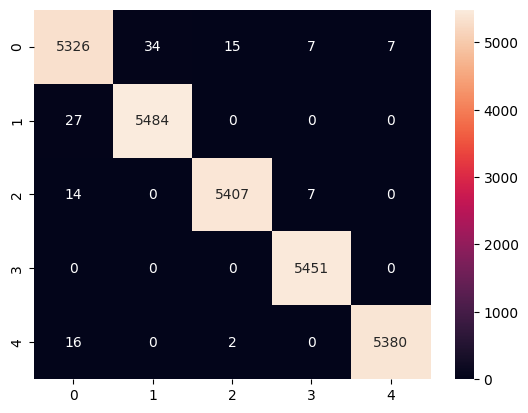

In [ ]:
y_pred_rfc = rfc_model.predict(x_test)
print(classification_report(y_test, y_pred_rfc))
sns.heatmap(confusion_matrix(y_test,y_pred_rfc), annot = True, fmt='d')